<div style="background: linear-gradient(135deg, #0d1117 0%, #1a1f2e 50%, #0d2137 100%);
     padding: 60px 40px; border-radius: 16px; text-align: center;
     border: 2px solid #30a3dc; box-shadow: 0 0 40px rgba(48,163,220,0.3);">

<h1 style="color:#ffffff; font-size:2.8em; font-weight:800; margin-bottom:10px;
   text-shadow:0 0 20px rgba(48,163,220,0.6); letter-spacing:1px;">
🔢 Seeing Through the Noise
</h1>

<h2 style="color:#30a3dc; font-size:1.6em; font-weight:400; margin-bottom:30px;">
How SVD Recovers Handwritten Digits from Heavy Noise
</h2>

<div style="border-top:1px solid #30a3dc; padding-top:24px; margin-top:10px;">
<p style="color:#8bb8d4; font-size:1.1em; margin:4px 0;">
📐 Singular Value Decomposition &nbsp;|&nbsp; 🔢 MNIST Digit 3 &nbsp;|&nbsp; 📊 Optimal k Selection
</p>
<p style="color:#566070; font-size:0.95em; margin-top:16px;">
Alfredo Saldana Nunez &nbsp;·&nbsp; Data Science project
</p>
</div>
</div>

---
## Cell 1 — Imports & Configuration
> *Setting the stage. Every great performance starts with tuning the instruments.*

In [3]:
# ============================================================
# CELL 1: Imports & Global Configuration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ipywidgets import interact, IntSlider
import warnings
warnings.filterwarnings('ignore')

# ── Try loading MNIST from keras, fallback to sklearn ────────
try:
    from tensorflow.keras.datasets import mnist
    USE_KERAS = True
    print("Using TensorFlow/Keras to load MNIST.")
except ImportError:
    from sklearn.datasets import fetch_openml
    USE_KERAS = False
    print("Using sklearn to load MNIST.")

# ── Global plot aesthetics ────────────────────────────────────
plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   16,
    'axes.labelsize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'text.color':       '#e0e0e0',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#e0e0e0',
    'ytick.color':      '#e0e0e0',
    'axes.edgecolor':   '#30a3dc',
    'grid.color':       '#1e2a38',
    'grid.linestyle':   '--',
    'lines.linewidth':  2.0,
    'figure.dpi':       120,
})

np.random.seed(42)
print("✅ Configuration complete. Ready to load data.")


Using TensorFlow/Keras to load MNIST.
✅ Configuration complete. Ready to load data.


---
## 🎬 The Problem — Can a Machine Read Through Noise?

<div style="background:#0f1923; border-left:4px solid #e74c3c;
     padding:20px 28px; border-radius:8px; margin:12px 0;">

<p style="color:#ffffff; font-size:1.05em;">
Imagine a surveillance camera captures a handwritten note — but the image is corrupted.
Pixel noise everywhere. The digits are barely recognizable.
</p>

<p style="color:#ffffff;"><b style="color:#2ecc71;">Can we recover the original digit?</b></p>

<p style="color:#ffffff;">This is not just an academic question. It appears in:</p>
<ul>
<li style="color:#ffffff;">📬 Postal digit recognition from worn envelopes</li>
<li style="color:#ffffff;">🏥 Medical form digitization with scan noise</li>
<li style="color:#ffffff;">🔍 Forensic document recovery from degraded sources</li>
</ul>

<p style="color:#ffffff;">The answer is <b>yes</b> — and the key is that <b>all handwritten 3s share a common structure</b>.
SVD finds that shared structure and uses it to separate signal from noise.</p>

<div style="border-left:3px solid #30a3dc; padding:8px 16px; margin:10px 0;">
<p style="color:#30a3dc; font-style:italic; margin:0;">
"Signal is low-rank. Noise is not. SVD knows the difference."
</p>
</div>

---
## Cell 2 — Load MNIST & Extract All Digit 3s

In [6]:
# ============================================================
# CELL 2: Load MNIST and Extract Digit 3
# ============================================================

# ── Load full MNIST dataset ───────────────────────────────────
if USE_KERAS:
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    # Flatten: each 28x28 image → row vector of 784 values
    # you could use the extended version of the following line to do reshape
    # X_all = X_train.reshape(X_train.shape[0], X_train.shape[1] * X_train.shape[2]).astype(np.float64)
    X_all = X_train.reshape(X_train.shape[0], -1).astype(np.float64)
    y_all = y_train
else:
    print("Fetching MNIST via sklearn (may take ~1 min first time)...")
    mnist_data = fetch_openml('mnist_784', version=1, as_frame=False)
    X_all = mnist_data.data.astype(np.float64)
    y_all = mnist_data.target.astype(int)

# ── Normalize pixels to [0, 1] ────────────────────────────────
X_all = X_all / 255.0

# ── Extract only digit 3 ─────────────────────────────────────
mask   = (y_all == 3)
X_3    = X_all[mask]        # shape: (N_3, 784)

print("── MNIST Dataset Loaded ───────────────────────────────")
print(f"   Full dataset shape   : {X_all.shape}")
print(f"   Number of digit 3s   : {X_3.shape[0]:,}")
print(f"   Image dimensions     : 28 × 28 = 784 pixels per image")
print(f"   Matrix shape (data)  : {X_3.shape}  ← rows=images, cols=pixels")
print(f"   Pixel range          : {X_3.min():.2f} to {X_3.max():.2f}")
print()
print("   Each ROW is one flattened 28×28 image.")
print("   We have a matrix of shape (N_images × 784).")
print("   SVD will find the shared structure across ALL digit 3s.")


── MNIST Dataset Loaded ───────────────────────────────
   Full dataset shape   : (60000, 784)
   Number of digit 3s   : 6,131
   Image dimensions     : 28 × 28 = 784 pixels per image
   Matrix shape (data)  : (6131, 784)  ← rows=images, cols=pixels
   Pixel range          : 0.00 to 1.00

   Each ROW is one flattened 28×28 image.
   We have a matrix of shape (N_images × 784).
   SVD will find the shared structure across ALL digit 3s.


---
## Cell 3 — Visualize the First 10 Clean Digit 3s

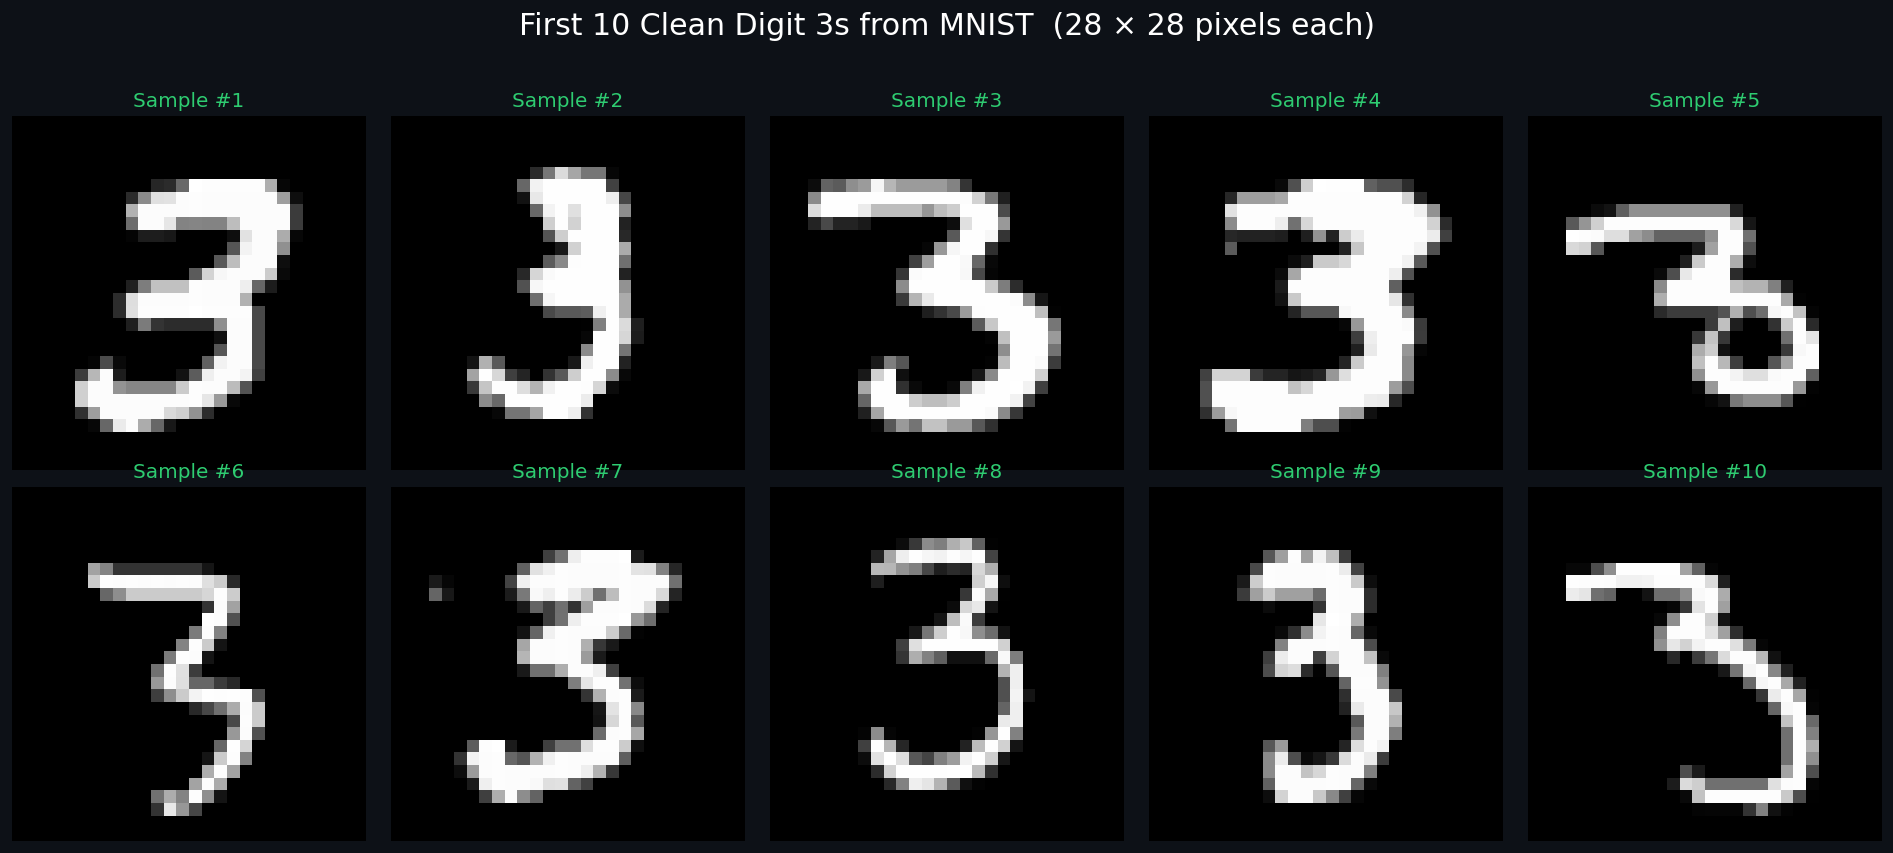

Notice: every image IS a 3, but each person wrote it differently.
That variation across images is exactly the structure SVD will find.


In [8]:
# ============================================================
# CELL 3: Display First 10 Clean Digit 3s
# ============================================================

N_SHOW = 10

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

for i, ax in enumerate(axes.flat):
    img = X_3[i].reshape(28, 28)    # unflatten back to 28×28
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Sample #{i+1}', fontsize=12, color='#2ecc71', pad=6)
    ax.axis('off')

fig.suptitle(
    f'First {N_SHOW} Clean Digit 3s from MNIST  (28 × 28 pixels each)',
    fontsize=18, color='white', y=1.02
)
plt.tight_layout()
plt.show()

print("Notice: every image IS a 3, but each person wrote it differently.")
print("That variation across images is exactly the structure SVD will find.")


## 📐 SVD Theory — The Mathematics (With Explicit Dimensions)

<div style="background:#0f1923; border-left:4px solid #30a3dc;
     padding:20px 28px; border-radius:8px; margin:12px 0; font-size:1.05em;">

<p style="color:#ffffff;">
Our data matrix <b style="color:#30a3dc;">X</b> has shape <b style="color:#30a3dc;">N × 784</b> 
where N ≈ 6,131 (all digit 3s).
</p>

<p style="color:#ffffff;">SVD decomposes it as:</p>

<div style="text-align:center; margin:16px 0;">
  <span style="font-size:1.4em; color:#ffffff; background:#0d2137; 
        padding:10px 24px; border-radius:8px; border:2px solid #30a3dc;
        font-family:Georgia, serif;">
    X = U · Σ · Vᵀ
  </span>
</div>

<table style="width:100%; border-collapse:collapse; margin-bottom:16px;">
<tr style="background:#0d2137;">
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc;">Matrix</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc;">Shape</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc;">What it contains</th>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;"><b>U</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">N × N</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Left singular vectors — one per image</td>
</tr>
<tr style="background:#0d2137;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;"><b>Σ</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">N × 784</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Diagonal of singular values σ₁ ≥ σ₂ ≥ … ≥ 0</td>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;"><b>Vᵀ</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">784 × 784</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Right singular vectors — directions in pixel space</td>
</tr>
</table>

<p style="color:#30a3dc; font-size:1.1em;"><b>Truncated (Rank-k) SVD — The Denoising Formula</b></p>

<div style="text-align:center; margin:16px 0;">
  <span style="font-size:1.4em; color:#ffffff; background:#0d2137; 
        padding:10px 24px; border-radius:8px; border:2px solid #2ecc71;
        font-family:Georgia, serif;">
    X̂ₖ = Uₖ · Σₖ · Vₖᵀ
  </span>
</div>

<table style="width:100%; border-collapse:collapse; margin-bottom:16px;">
<tr style="background:#0d2137;">
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc;">Matrix</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc;">Shape</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc;">Meaning</th>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;"><b>Uₖ</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">N × k</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">First k columns of U</td>
</tr>
<tr style="background:#0d2137;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;"><b>Σₖ</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">k × k</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Top-left k × k block</td>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;"><b>Vₖᵀ</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">k × 784</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">First k rows of Vᵀ</td>
</tr>
</table>

<div style="background:#0d2137; border-radius:6px; padding:14px 18px; margin-top:12px;">
<p style="color:#f39c12; margin:0 0 6px 0;"><b>⭐ Why does this work for digit denoising?</b></p>
<p style="color:#ffffff; margin:0;">
All handwritten 3s share a common shape — that's the <b style="color:#2ecc71;">low-rank signal</b>.<br>
Noise is random and different in every image — that's the <b style="color:#e74c3c;">high-rank component</b>.<br>
SVD separates them automatically.
</p>
</div>

</div>

---
## Cell 4 — Add Gaussian Noise to All Digit 3s

── Noise Added ────────────────────────────────────────
   Noise sigma          : 0.2 (Gaussian, mean=0)
   Clean matrix shape   : (6131, 784)
   Noisy matrix shape   : (6131, 784)  (same — noise added in-place)



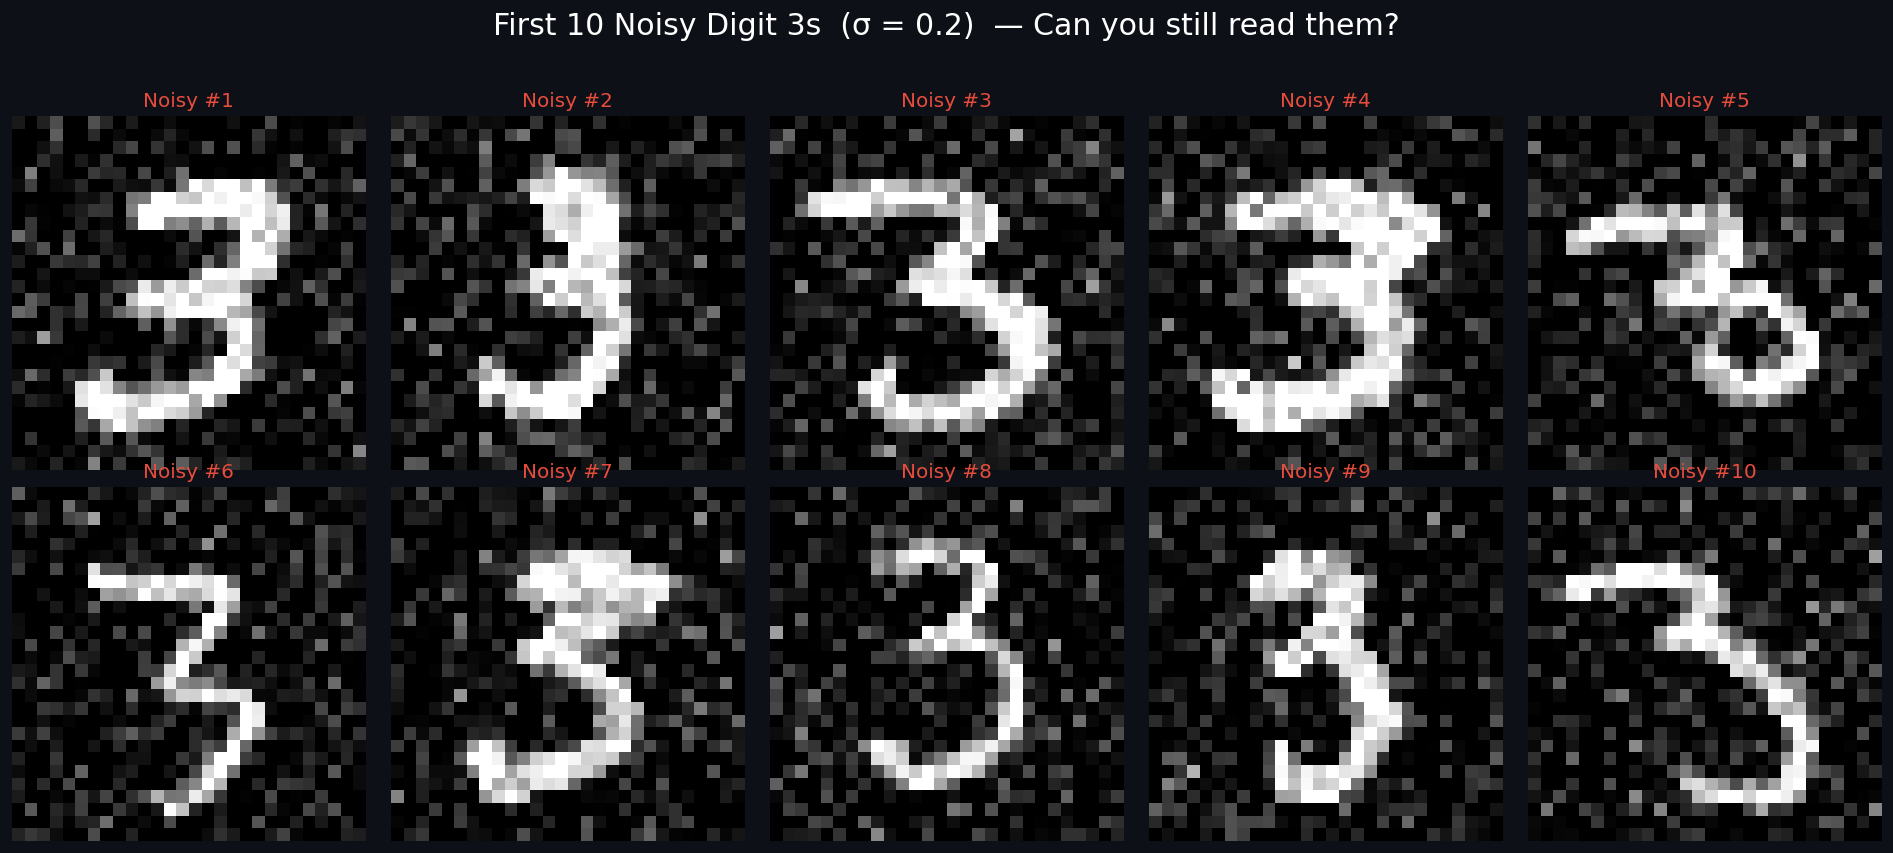

In [11]:
# ============================================================
# CELL 4: Add Gaussian Noise to the Digit-3 Matrix
# ============================================================

NOISE_SIGMA = 0.2   # 20% noise — heavy but the digit is still visible

# Add Gaussian noise to every pixel of every image
X_3_noisy = X_3 + np.random.normal(loc=0.0,
                                     scale=NOISE_SIGMA,
                                     size=X_3.shape)

# Clip to [0, 1] — noise can push values out of valid range
X_3_noisy = np.clip(X_3_noisy, 0.0, 1.0)

print("── Noise Added ────────────────────────────────────────")
print(f"   Noise sigma          : {NOISE_SIGMA} (Gaussian, mean=0)")
print(f"   Clean matrix shape   : {X_3.shape}")
print(f"   Noisy matrix shape   : {X_3_noisy.shape}  (same — noise added in-place)")
print()

# ── Show first 10 noisy digits ───────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_3_noisy[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Noisy #{i+1}', fontsize=12, color='#e74c3c', pad=6)
    ax.axis('off')

fig.suptitle(
    f'First 10 Noisy Digit 3s  (σ = {NOISE_SIGMA})  — Can you still read them?',
    fontsize=18, color='white', y=1.02
)
plt.tight_layout()
plt.show()


---
## Cell 5 — Compute SVD of the Noisy Matrix

In [13]:
# ============================================================
# CELL 5: Compute SVD on the Noisy Digit-3 Matrix
# ============================================================
# We apply SVD to the ENTIRE matrix of noisy digit 3s at once.
# This is the key difference from the single-image approach:
# SVD now finds structure ACROSS all ~6,000 images.

print("Computing SVD on noisy matrix... (may take a few seconds)")
U, S, Vt = np.linalg.svd(X_3_noisy, full_matrices=False)

N, P  = X_3_noisy.shape   # N images, P=784 pixels
k_max = len(S)

print()
print("── SVD Decomposition Complete ─────────────────────────")
print(f"   Input matrix X     : {N} × {P}")
print(f"   U                  : {U.shape}   ← image directions")
print(f"   S (singular values): {S.shape}    ← importance weights")
print(f"   Vt                 : {Vt.shape}  ← pixel directions")
print()
print(f"   Top 10 singular values:")
for i, sv in enumerate(S[:10]):
    bar = '█' * int(sv / S[0] * 35)
    print(f"   σ_{i+1:>2} = {sv:8.2f}  {bar}")
print(f"   ... ({k_max} total)")

# Precompute cumulative energy for later cells
total_energy = np.sum(S**2)
cum_energy   = np.cumsum(S**2) / total_energy
k90  = np.searchsorted(cum_energy, 0.90) + 1
k95  = np.searchsorted(cum_energy, 0.95) + 1
k99  = np.searchsorted(cum_energy, 0.99) + 1

print()
print(f"   k for 90% energy : {k90}")
print(f"   k for 95% energy : {k95}")
print(f"   k for 99% energy : {k99}")


Computing SVD on noisy matrix... (may take a few seconds)

── SVD Decomposition Complete ─────────────────────────
   Input matrix X     : 6131 × 784
   U                  : (6131, 784)   ← image directions
   S (singular values): (784,)    ← importance weights
   Vt                 : (784, 784)  ← pixel directions

   Top 10 singular values:
   σ_ 1 =   593.72  ███████████████████████████████████
   σ_ 2 =   157.21  █████████
   σ_ 3 =   134.25  ███████
   σ_ 4 =   107.37  ██████
   σ_ 5 =   101.26  █████
   σ_ 6 =    84.84  █████
   σ_ 7 =    77.90  ████
   σ_ 8 =    74.70  ████
   σ_ 9 =    72.88  ████
   σ_10 =    69.59  ████
   ... (784 total)

   k for 90% energy : 171
   k for 95% energy : 374
   k for 99% energy : 667


---
## Cell 6 — Reconstruction Function

In [15]:
# ============================================================
# CELL 6: Define Reconstruction & Quality Metrics
# ============================================================

def reconstruct(k):
    """
    Reconstruct all digit-3 images using top-k SVD components.

    Formula : X_k = U[:, :k]  @  diag(S[:k])  @  Vt[:k, :]
    Shapes  : (N×k)            @  (k×k)        @  (k×784) → (N×784)
    """
    approx = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    return np.clip(approx, 0.0, 1.0)

def mse(original, reconstructed):
    """Mean Squared Error — lower is better."""
    return np.mean((original - reconstructed) ** 2)

def psnr(original, reconstructed):
    """Peak Signal-to-Noise Ratio in dB — higher is better."""
    m = mse(original, reconstructed)
    if m == 0:
        return float('inf')
    return 10 * np.log10(1.0 / m)

# ── Sanity check across several k values ─────────────────────
print("── Reconstruction Quality vs k ────────────────────────")
print(f"   {'k':>6}  {'MSE':>10}  {'PSNR (dB)':>12}  {'Energy':>10}")
print(f"   {'─'*6}  {'─'*10}  {'─'*12}  {'─'*10}")

for test_k in [1, 2, 3, 5, 10, 20,50]:
    recon = reconstruct(test_k)
    m = mse(X_3, recon)
    p = psnr(X_3, recon)
    e = cum_energy[test_k-1] * 100
    print(f"   {test_k:>6}  {m:>10.5f}  {p:>10.2f} dB  {e:>9.1f}%")

print()
print("✅ Function ready. Notice PSNR improves rapidly with small k.")


── Reconstruction Quality vs k ────────────────────────
        k         MSE     PSNR (dB)      Energy
   ──────  ──────────  ────────────  ──────────
        1     0.05787       12.38 dB       57.2%
        2     0.05092       12.93 dB       61.2%
        3     0.04587       13.38 dB       64.1%
        5     0.03980       14.00 dB       67.6%
       10     0.03188       14.96 dB       72.4%
       20     0.02381       16.23 dB       77.4%
       50     0.01569       18.04 dB       83.3%

✅ Function ready. Notice PSNR improves rapidly with small k.


---
## Cell 7 — Clean vs Noisy vs Denoised Comparison

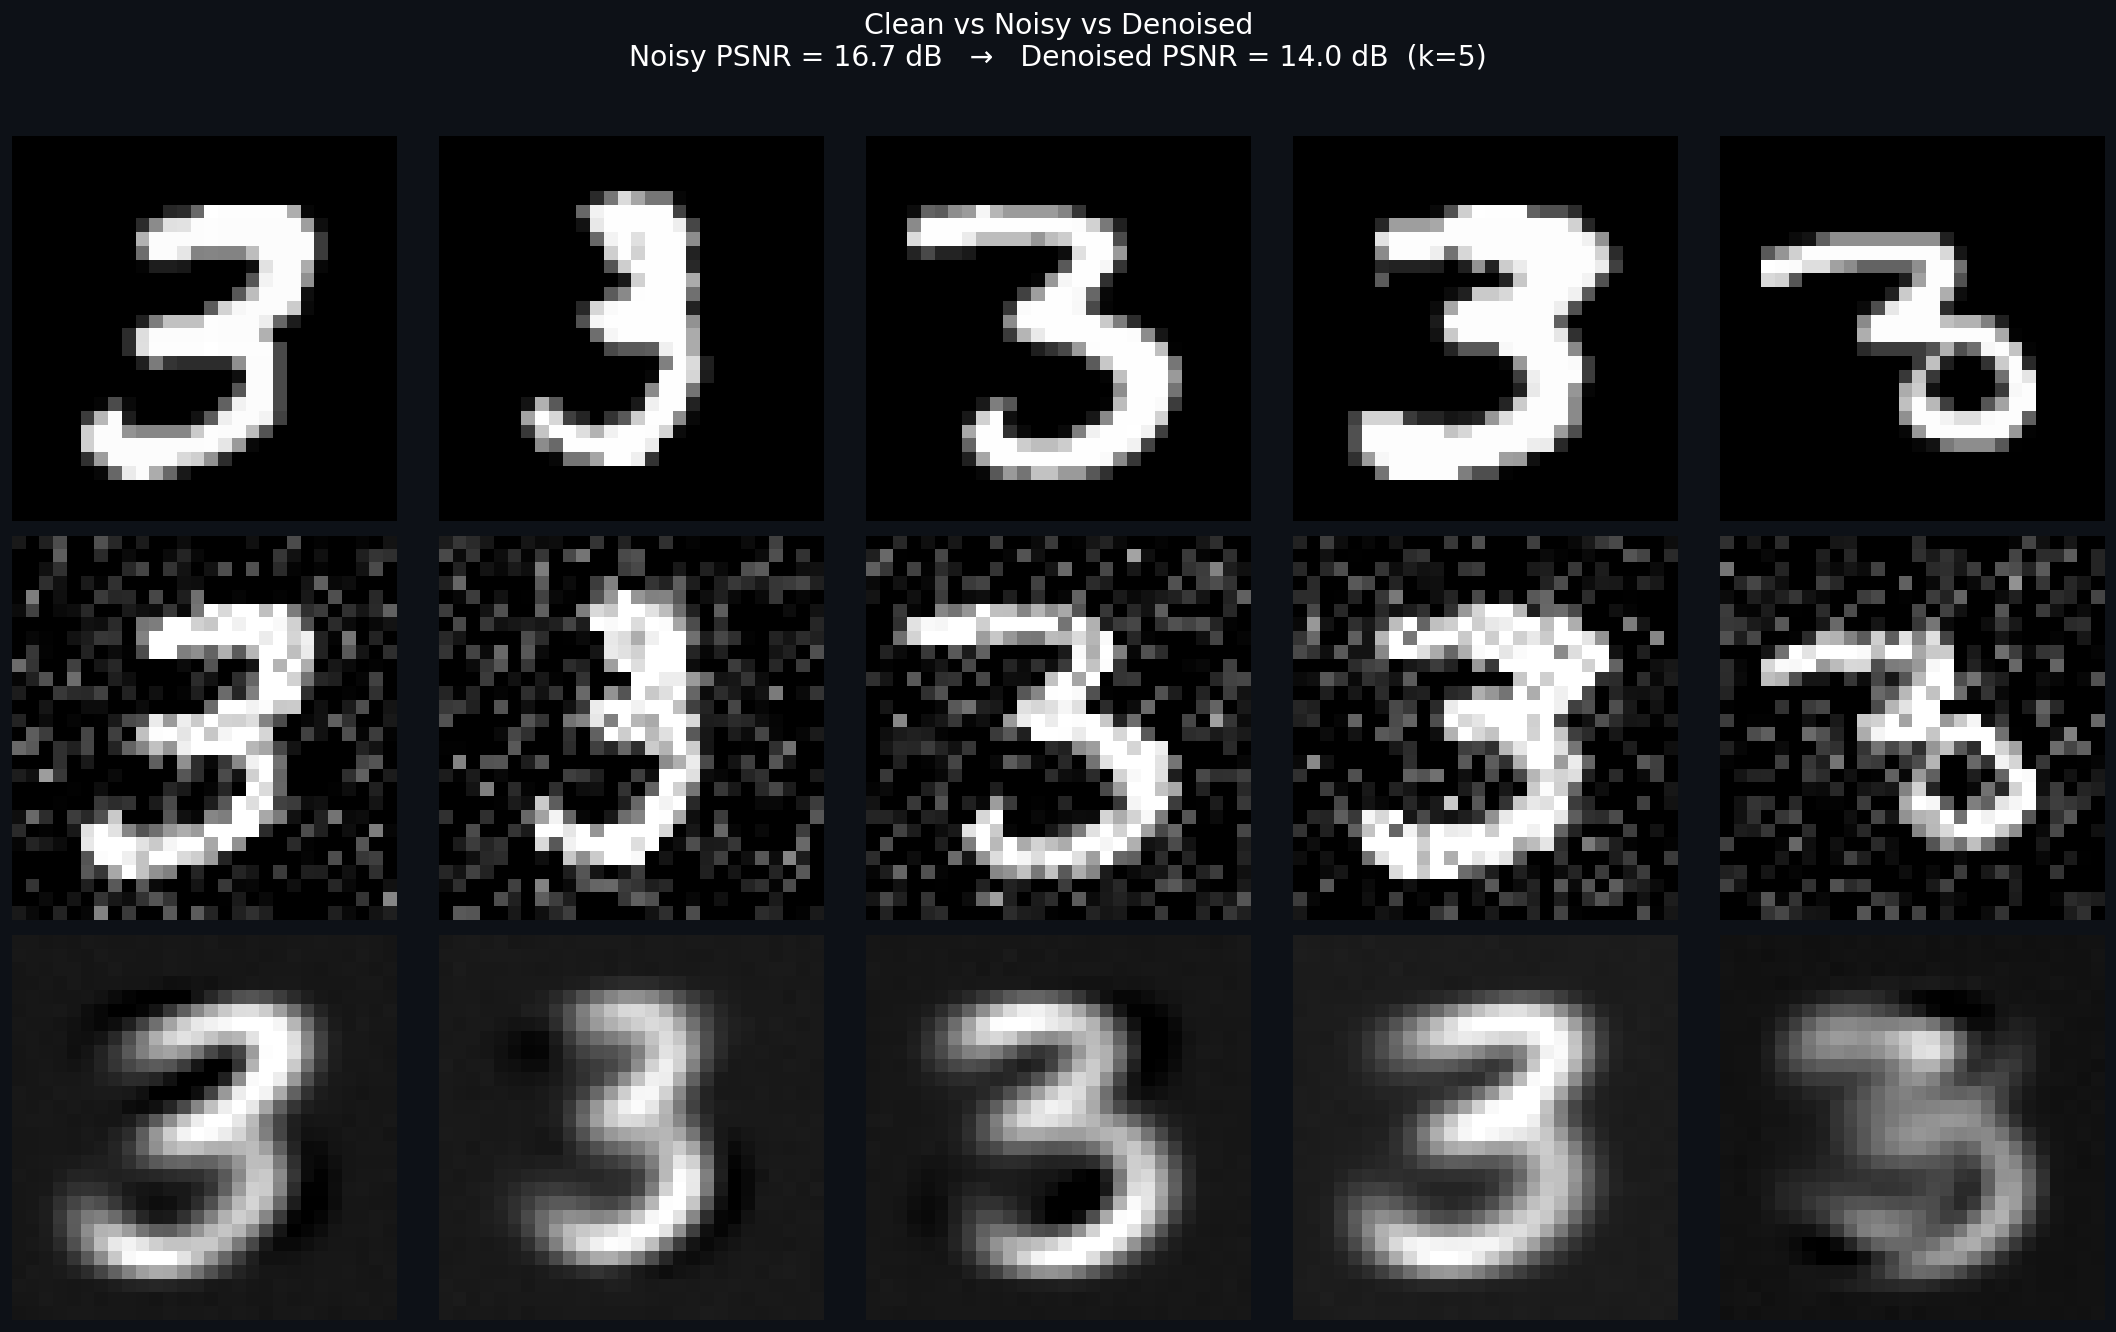

PSNR improvement: 16.71 dB  →  14.00 dB  (+-2.71 dB)


In [17]:
# ============================================================
# CELL 7: Side-by-Side — Clean vs Noisy vs Denoised (k=5)
# ============================================================

K_DEMO = 5       # start with a small k to show the concept
N_IMGS = 5       # show first 5 images

recon_demo = reconstruct(K_DEMO)

fig, axes = plt.subplots(3, N_IMGS, figsize=(18, 11))
fig.patch.set_facecolor('#0d1117')

row_labels  = ['✅  Clean', f'❌  Noisy (σ={NOISE_SIGMA})', f'🔧  Denoised (k={K_DEMO})']
row_colors  = ['#2ecc71', '#e74c3c', '#30a3dc']
row_data    = [X_3, X_3_noisy, recon_demo]

for row in range(3):
    for col in range(N_IMGS):
        ax = axes[row, col]
        ax.imshow(row_data[row][col].reshape(28, 28),
                  cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(row_labels[row],
                          color=row_colors[row],
                          fontsize=13, rotation=0,
                          labelpad=120, va='center')

p_noisy  = psnr(X_3, X_3_noisy)
p_denoised = psnr(X_3, recon_demo)

fig.suptitle(
    f'Clean vs Noisy vs Denoised\n'
    f'Noisy PSNR = {p_noisy:.1f} dB   →   Denoised PSNR = {p_denoised:.1f} dB  (k={K_DEMO})',
    fontsize=17, color='white', y=1.01
)
plt.tight_layout()
plt.show()

print(f"PSNR improvement: {p_noisy:.2f} dB  →  {p_denoised:.2f} dB  (+{p_denoised-p_noisy:.2f} dB)")


## Cell 8 — 🎬 SVD Denoising: The Step-by-Step Story

<div style="background:#0f1923; border-left:4px solid #2ecc71;
     padding:20px 28px; border-radius:8px; margin:12px 0;">

<p style="color:#ffffff; font-size:1.05em;">
Now comes the moment everything has been building toward.
</p>

<p style="color:#ffffff;">
We show <b style="color:#2ecc71;">4 key moments</b> in the denoising story —
each one a different value of k, from too small to too large.
For each k we display:
</p>

<p style="color:#ffffff;">
&nbsp;&nbsp;&nbsp;🔴 <b style="color:#e74c3c;">Top row</b>
<span style="color:#ffffff;"> — the noisy input (always the same — our corrupted reference)</span>
</p>

<p style="color:#ffffff;">
&nbsp;&nbsp;&nbsp;🔧 <b style="color:#30a3dc;">Bottom row</b>
<span style="color:#ffffff;"> — the SVD reconstruction at that k value</span>
</p>

<table style="width:100%; border-collapse:collapse; margin-top:14px; margin-bottom:6px;">
<tr style="background:#0d2137;">
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc; text-align:left;">Figure</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc; text-align:left;">k value</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc; text-align:left;">What you will see</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc; text-align:left;">Why</th>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#e74c3c; padding:8px; border:1px solid #1e3a52;"><b>Figure 1</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">k = 1</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Very blurry, over-smoothed</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Only 1 component — the coarsest pattern</td>
</tr>
<tr style="background:#0d2137;">
  <td style="color:#f39c12; padding:8px; border:1px solid #1e3a52;"><b>Figure 2</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">k = 5</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Getting better — shape emerging</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">5 components capture the main strokes</td>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;"><b>Figure 3</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">k = 20</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Clean, sharp, readable digit 3s</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Optimal zone — signal recovered, noise discarded</td>
</tr>
<tr style="background:#0d2137;">
  <td style="color:#e74c3c; padding:8px; border:1px solid #1e3a52;"><b>Figure 4</b></td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">k = 40</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Noise returning — degraded quality</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Too many components — noise included</td>
</tr>
</table>

<div style="background:#0d2137; border-radius:6px; padding:12px 16px; margin-top:14px;">
<p style="color:#f39c12; margin:0 0 6px 0;"><b>⭐ What to look for</b></p>
<p style="color:#ffffff; margin:0;">
Watch how the <b style="color:#2ecc71;">bottom row evolves</b> across the four figures.<br>
The top row never changes — it is always the corrupted input.<br>
Only the bottom row changes — showing what SVD recovers at each k.<br><br>
The <b style="color:#2ecc71;">PSNR number</b> in each title tells you the quality mathematically.<br>
The <b style="color:#2ecc71;">improvement</b> shows how many dB better we are than the noisy baseline.
</p>
</div>

</div>


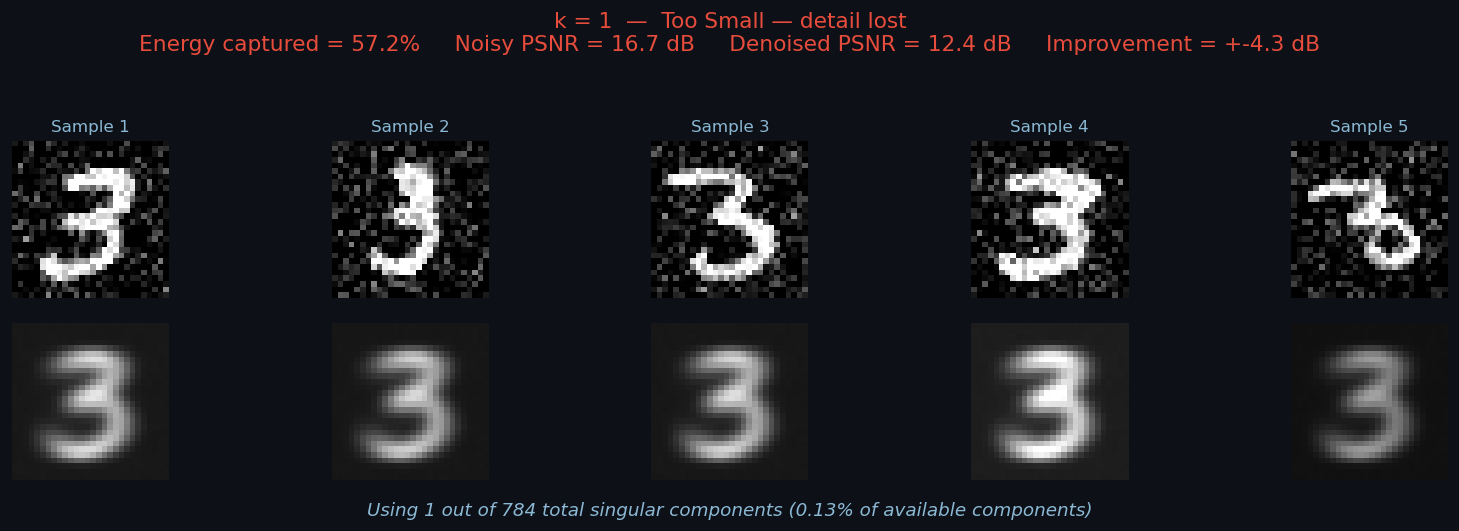

  k=  1 | Energy=57.2% | PSNR=12.38 dB | Improvement=+-4.33 dB



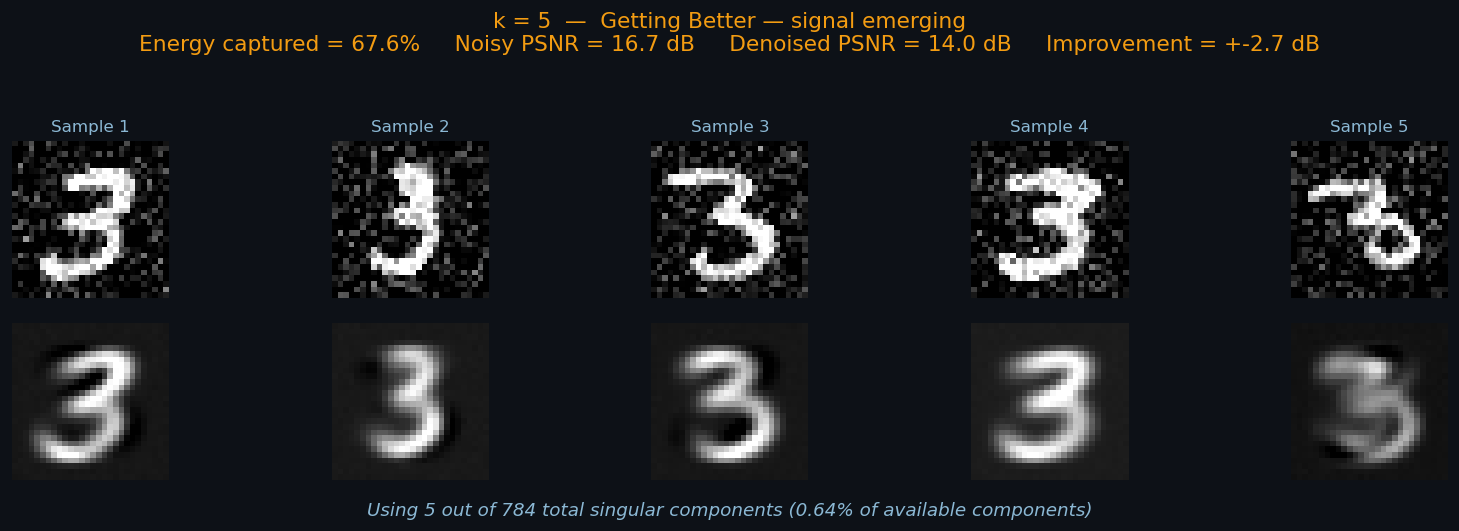

  k=  5 | Energy=67.6% | PSNR=14.00 dB | Improvement=+-2.71 dB



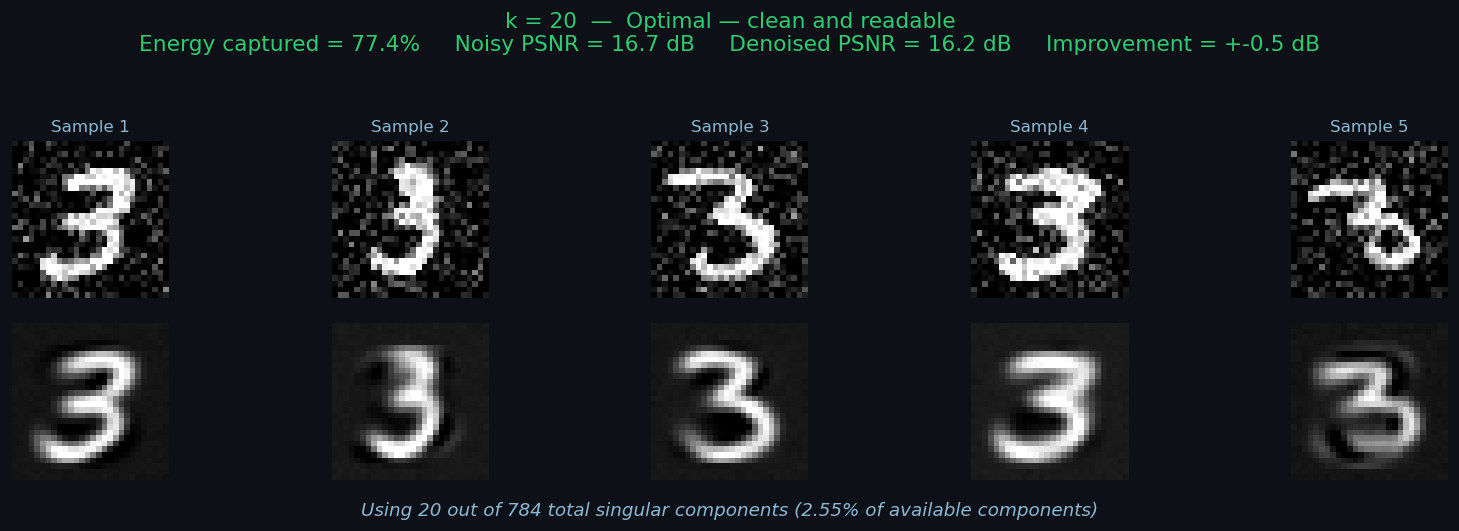

  k= 20 | Energy=77.4% | PSNR=16.23 dB | Improvement=+-0.47 dB



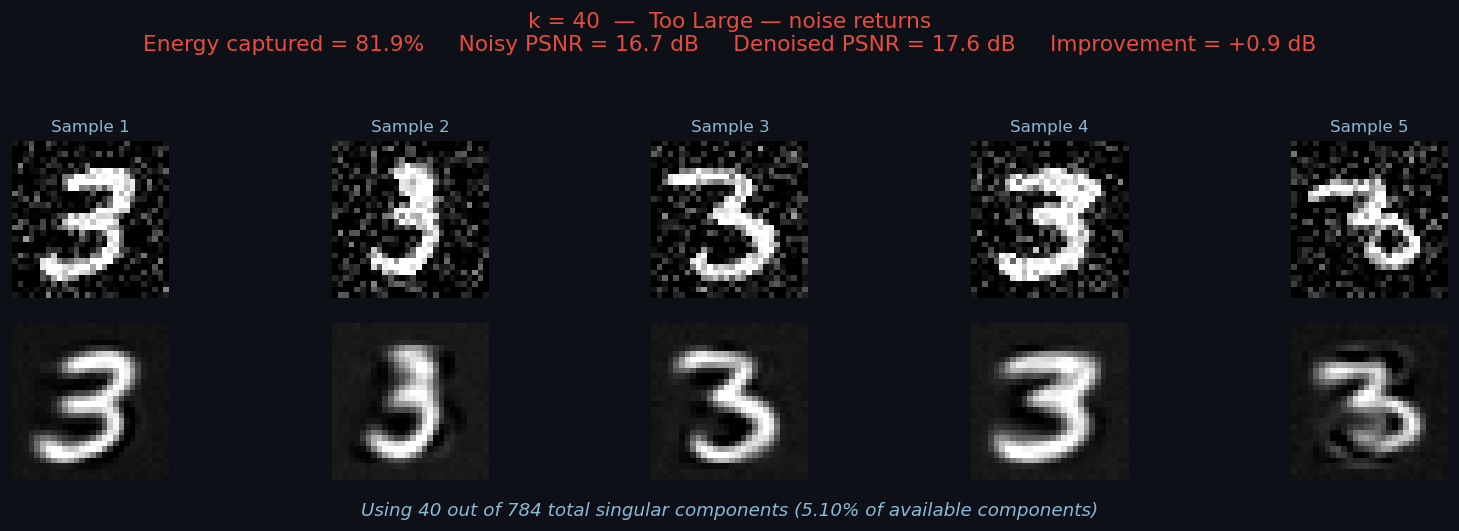

  k= 40 | Energy=81.9% | PSNR=17.60 dB | Improvement=+0.90 dB



In [19]:
# ============================================================
# CELL 8: SVD Denoising — Step by Step Demonstration
# ============================================================
from IPython.display import display, HTML
display(HTML("<style>div.output_scroll { height: auto !important; max-height: none !important; }</style>"))
# We show 4 key moments in the denoising story
# Each moment = one figure, clean and readable

k_values = [1, 5, 20, 40]    # K values selected for display only, optimal K will be selected later
labels   = ['Too Small — detail lost',
            'Getting Better — signal emerging', 
            'Optimal — clean and readable',
            'Too Large — noise returns']
colors   = ['#e74c3c', '#f39c12', '#2ecc71', '#e74c3c']
N_SHOW   = 5

p_noisy = psnr(X_3, X_3_noisy)

for k, label, color in zip(k_values, labels, colors):

    recon      = reconstruct(k)
    p_denoised = psnr(X_3, recon)
    energy_pct = cum_energy[k-1] * 100

    fig, axes = plt.subplots(2, N_SHOW, figsize=(14, 4))
    fig.patch.set_facecolor('#0d1117')

    for col in range(N_SHOW):

        # ── Top row: noisy ───────────────────────────────────
        axes[0, col].imshow(X_3_noisy[col].reshape(28, 28),
                             cmap='gray', vmin=0, vmax=1)
        axes[0, col].axis('off')
        if col == 0:
            axes[0, col].set_title('Sample 1', color='#8bb8d4',
                                    fontsize=10, pad=6)
        else:
            axes[0, col].set_title(f'Sample {col+1}',
                                    color='#8bb8d4', fontsize=10, pad=6)

        # ── Bottom row: denoised ─────────────────────────────
        axes[1, col].imshow(recon[col].reshape(28, 28),
                             cmap='gray', vmin=0, vmax=1)
        axes[1, col].axis('off')

    # ── Row labels ───────────────────────────────────────────
    axes[0, 0].set_ylabel('❌  Noisy Input',
                           color='#e74c3c', fontsize=12,
                           rotation=0, labelpad=100, va='center')
    axes[1, 0].set_ylabel('🔧  Reconstructed',
                           color=color, fontsize=12,
                           rotation=0, labelpad=100, va='center')

    # ── Main title ───────────────────────────────────────────
    fig.suptitle(
        f'k = {k}  —  {label}\n'
        f'Energy captured = {energy_pct:.1f}%     '
        f'Noisy PSNR = {p_noisy:.1f} dB     '
        f'Denoised PSNR = {p_denoised:.1f} dB     '
        f'Improvement = +{p_denoised - p_noisy:.1f} dB',
        fontsize=13, color=color, y=1.03
    )

    # ── Bottom annotation ────────────────────────────────────
    fig.text(0.5, -0.02,
             f'Using {k} out of {len(S):,} total singular components '
             f'({100*k/len(S):.2f}% of available components)',
             ha='center', fontsize=11, color='#8bb8d4',
             style='italic')

    plt.tight_layout()
    plt.show()
    print(f'  k={k:>3} | Energy={energy_pct:.1f}% | '
          f'PSNR={p_denoised:.2f} dB | '
          f'Improvement=+{p_denoised-p_noisy:.2f} dB')
    print()

## 🔍 How Do We Choose the Right k?  —  Three Methods

<div style="background:#0f1923; border-left:4px solid #f39c12;
     padding:20px 28px; border-radius:8px; margin:12px 0;">

<p style="color:#ffffff;">
Choosing <b style="color:#f39c12;">k</b> is the critical question. Three principled strategies:
</p>

<p style="color:#ffffff;">
<b style="color:#2ecc71;">1. Elbow / Scree Plot</b> 
<span style="color:#ffffff;">— find where singular values drop sharply to a flat floor</span>
</p>

<p style="color:#ffffff;">
<b style="color:#2ecc71;">2. Cumulative Energy</b> 
<span style="color:#ffffff;">— keep enough components to explain 90–95% of total variance</span>
</p>

<p style="color:#ffffff;">
<b style="color:#2ecc71;">3. PSNR vs k</b> 
<span style="color:#ffffff;">— sweep all values of k and find the one that maximises reconstruction quality</span>
</p>

<div style="background:#0d2137; border-radius:6px; padding:12px 16px; margin-top:14px;">
<p style="color:#f39c12; margin:0;">
⭐ All three should agree on roughly the same value. 
<span style="color:#ffffff;">That convergence is your confidence check.</span>
</p>
</div>

</div>

---
## Cell 9 — Method 1: Elbow / Scree Plot

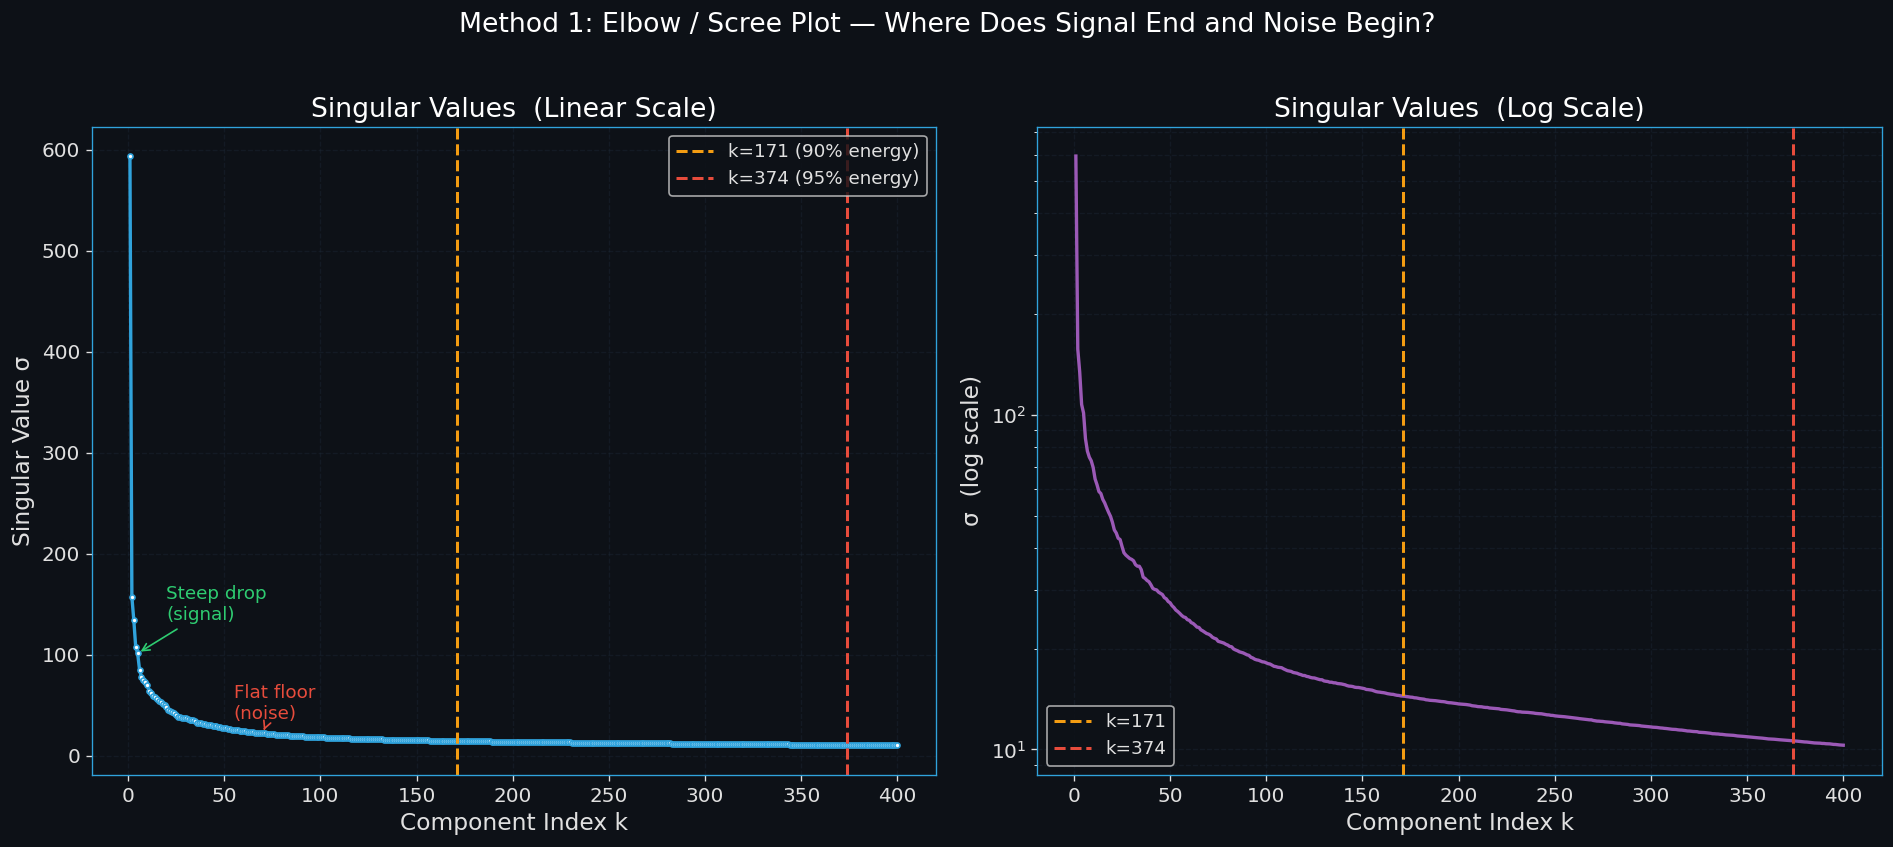

Elbow suggests cutting around k = 171 to 374


In [22]:
# ============================================================
# CELL 9: Singular Value Elbow (Scree) Plot
# ============================================================

N_SHOW = 400    # show first 100 singular values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: linear scale ───────────────────────────────────────
axes[0].plot(range(1, N_SHOW+1), S[:N_SHOW],
             color='#30a3dc', linewidth=2,
             marker='o', markersize=3, markerfacecolor='white')
axes[0].axvline(x=k90, color='#f39c12', linestyle='--',
                linewidth=1.8, label=f'k={k90} (90% energy)')
axes[0].axvline(x=k95, color='#e74c3c', linestyle='--',
                linewidth=1.8, label=f'k={k95} (95% energy)')
axes[0].set_title('Singular Values  (Linear Scale)', color='white')
axes[0].set_xlabel('Component Index k')
axes[0].set_ylabel('Singular Value σ')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

# Annotate signal vs noise regions
axes[0].annotate('Steep drop\n(signal)',
                  xy=(5, S[4]), xytext=(20, S[2]),
                  arrowprops=dict(arrowstyle='->', color='#2ecc71'),
                  color='#2ecc71', fontsize=11)
axes[0].annotate('Flat floor\n(noise)',
                  xy=(70, S[69]), xytext=(55, S[30]),
                  arrowprops=dict(arrowstyle='->', color='#e74c3c'),
                  color='#e74c3c', fontsize=11)

# ── Right: log scale ─────────────────────────────────────────
axes[1].semilogy(range(1, N_SHOW+1), S[:N_SHOW],
                 color='#9b59b6', linewidth=2)
axes[1].axvline(x=k90, color='#f39c12', linestyle='--',
                linewidth=1.8, label=f'k={k90}')
axes[1].axvline(x=k95, color='#e74c3c', linestyle='--',
                linewidth=1.8, label=f'k={k95}')
axes[1].set_title('Singular Values  (Log Scale)', color='white')
axes[1].set_xlabel('Component Index k')
axes[1].set_ylabel('σ  (log scale)')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.4, which='both')

fig.suptitle('Method 1: Elbow / Scree Plot — Where Does Signal End and Noise Begin?',
             fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.show()

print(f"Elbow suggests cutting around k = {k90} to {k95}")


---
## Cell 10 — Method 2: Cumulative Energy

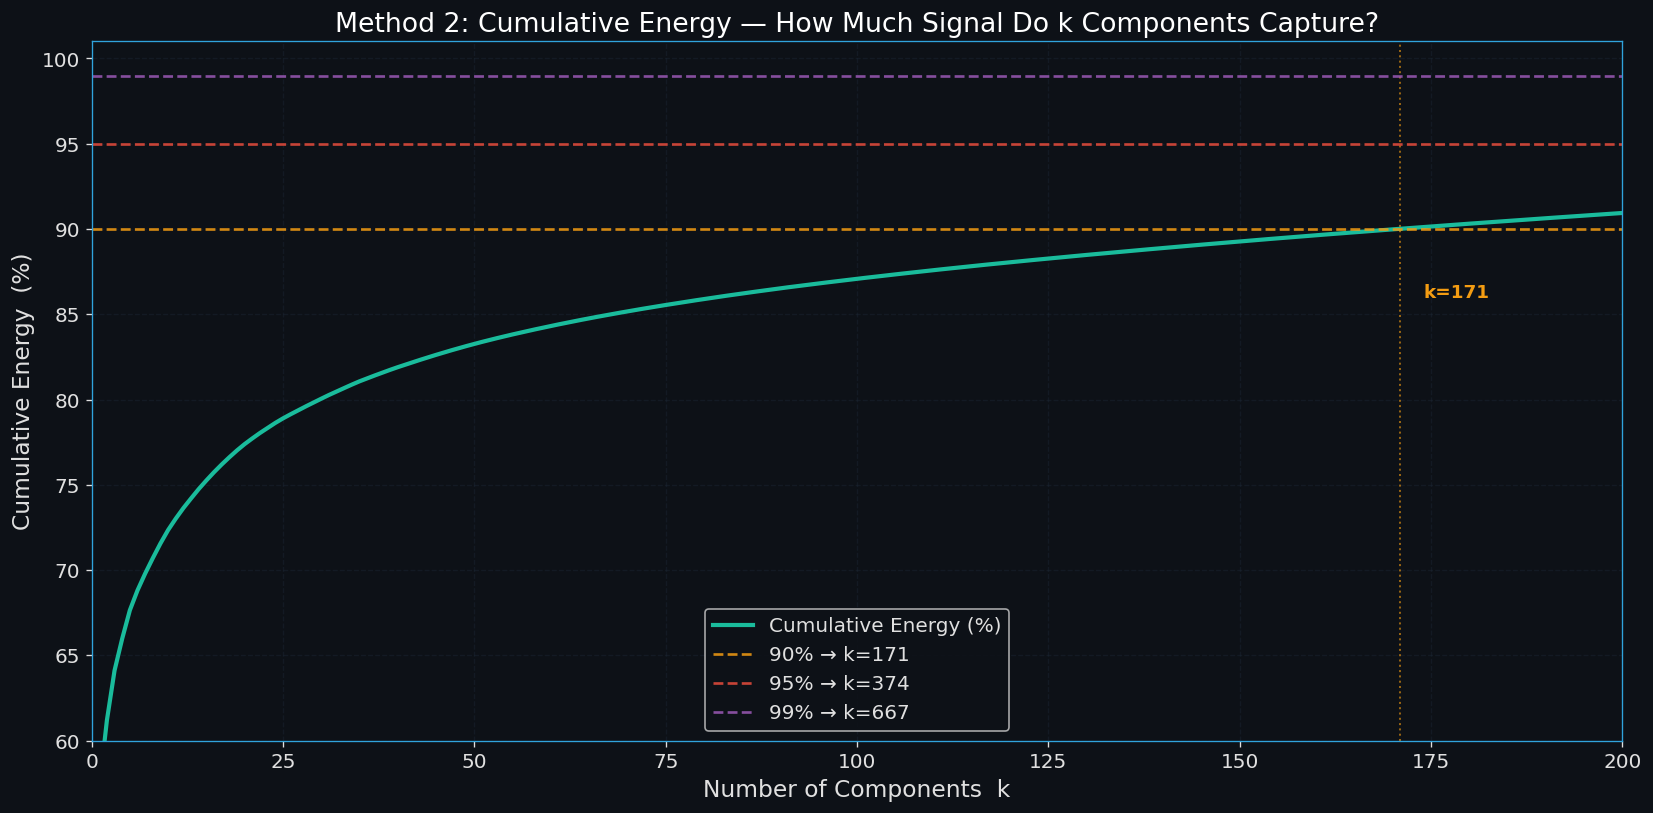

   90% energy at k = 171
   95% energy at k = 374
   99% energy at k = 667


In [24]:
# ============================================================
# CELL 10: Cumulative Energy Plot
# ============================================================

k_range = np.arange(1, min(200, k_max) + 1)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(k_range, cum_energy[:len(k_range)] * 100,
        color='#1abc9c', linewidth=2.5, label='Cumulative Energy (%)')

for threshold, color, label in [(90, '#f39c12', '90%'),
                                  (95, '#e74c3c', '95%'),
                                  (99, '#9b59b6', '99%')]:
    k_t = np.searchsorted(cum_energy, threshold/100) + 1
    ax.axhline(y=threshold, color=color, linestyle='--',
               linewidth=1.6, alpha=0.85, label=f'{label} → k={k_t}')
    ax.axvline(x=k_t, color=color, linestyle=':', linewidth=1.2, alpha=0.6)
    ax.annotate(f'k={k_t}', xy=(k_t, threshold),
                xytext=(k_t+3, threshold-4),
                color=color, fontsize=11, fontweight='bold')

ax.set_xlim(0, 200)
ax.set_ylim(60, 101)
ax.set_xlabel('Number of Components  k')
ax.set_ylabel('Cumulative Energy  (%)')
ax.set_title('Method 2: Cumulative Energy — How Much Signal Do k Components Capture?',
             fontsize=16, color='white')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"   90% energy at k = {k90}")
print(f"   95% energy at k = {k95}")
print(f"   99% energy at k = {k99}")


---
## Cell 11 — Method 3: PSNR vs k

Sweeping k values... (may take ~15 seconds)
Done ✅


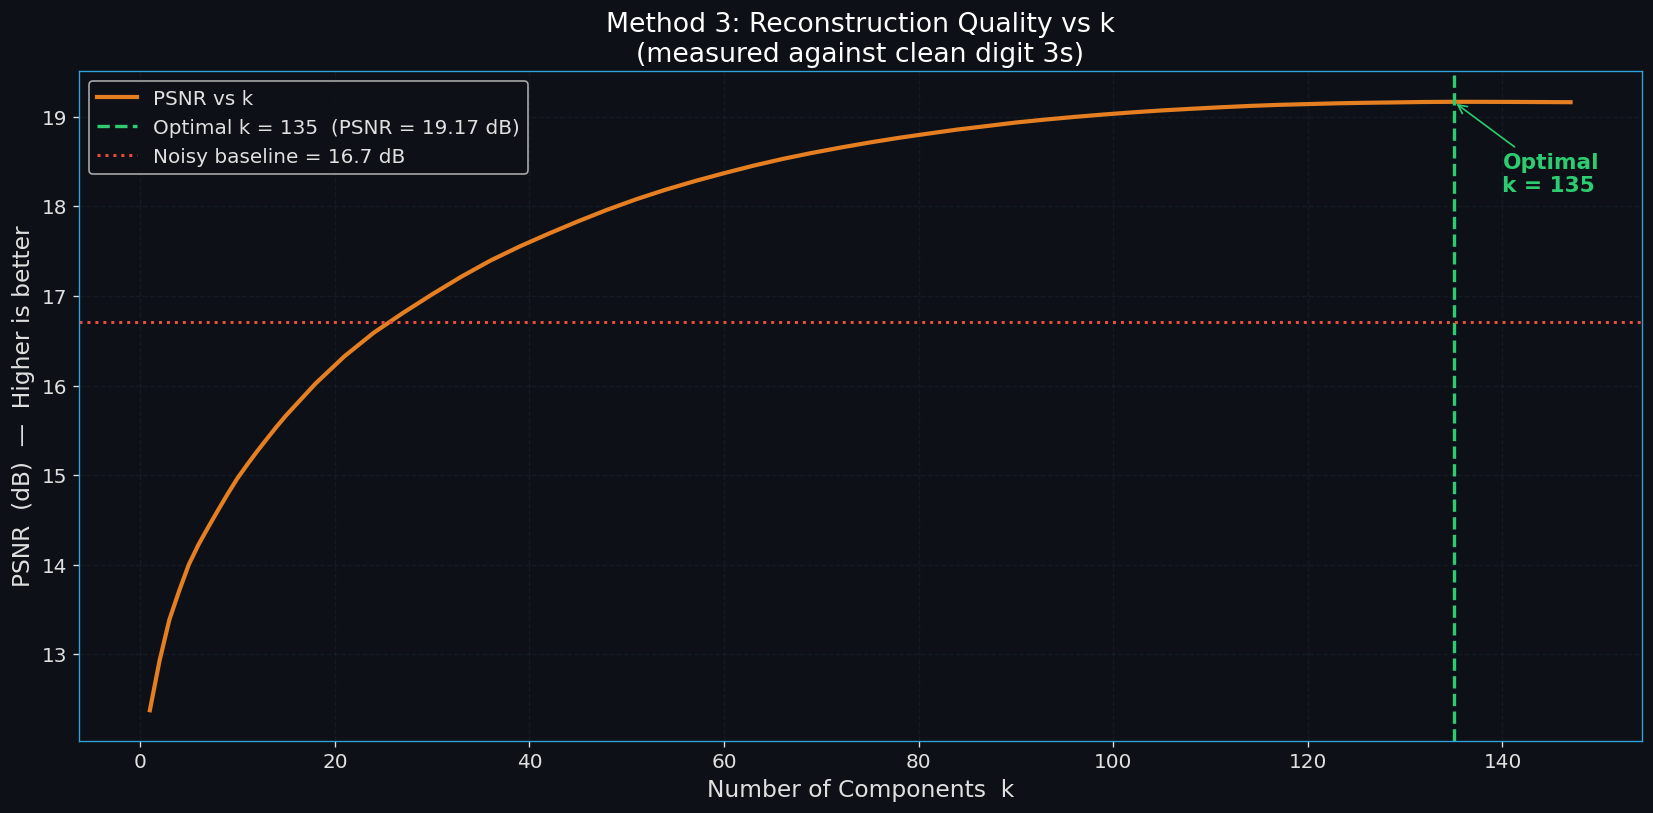

Optimal k = 135  →  PSNR = 19.17 dB
PSNR improvement over noisy: +2.46 dB


In [26]:
# ============================================================
# CELL 11: PSNR vs k — Find the Empirically Optimal k
# ============================================================

K_SWEEP   = list(range(1, 15)) + list(range(15, 150, 3))
psnr_vals = []

print("Sweeping k values... (may take ~15 seconds)")
for k in K_SWEEP:
    recon = reconstruct(k)
    psnr_vals.append(psnr(X_3, recon))
print("Done ✅")

best_k    = K_SWEEP[np.argmax(psnr_vals)]
best_psnr = max(psnr_vals)
p_noisy   = psnr(X_3, X_3_noisy)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(K_SWEEP, psnr_vals, color='#e67e22', linewidth=2.5,
        label='PSNR vs k')
ax.axvline(x=best_k, color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Optimal k = {best_k}  (PSNR = {best_psnr:.2f} dB)')
ax.axhline(y=p_noisy, color='#e74c3c', linestyle=':', linewidth=1.8,
           label=f'Noisy baseline = {p_noisy:.1f} dB')

ax.annotate(f'Optimal\nk = {best_k}',
             xy=(best_k, best_psnr),
             xytext=(best_k + 5, best_psnr - 1),
             arrowprops=dict(arrowstyle='->', color='#2ecc71'),
             color='#2ecc71', fontsize=13, fontweight='bold')

ax.set_xlabel('Number of Components  k')
ax.set_ylabel('PSNR  (dB)  —  Higher is better')
ax.set_title('Method 3: Reconstruction Quality vs k\n(measured against clean digit 3s)',
             fontsize=16, color='white')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Optimal k = {best_k}  →  PSNR = {best_psnr:.2f} dB")
print(f"PSNR improvement over noisy: +{best_psnr - p_noisy:.2f} dB")


---
## Cell 12 — Automatic Optimal k Selection

In [28]:
# ============================================================
# CELL 12: Automatic Optimal-k Selection
# ============================================================

def find_optimal_k(S, method='energy', threshold=0.95):
    """
    Automatically find optimal number of SVD components.

    Methods:
        'energy' : cumulative energy >= threshold
        'elbow'  : largest drop in consecutive singular values
        'psnr'   : pre-computed from sweep above
    """
    if method == 'energy':
        cum = np.cumsum(S**2) / np.sum(S**2)
        k   = int(np.searchsorted(cum, threshold)) + 1
        print(f"[energy]  k = {k:>4}  →  captures {threshold*100:.0f}% of total energy")
        return k
    elif method == 'elbow':
        diffs = np.diff(S)
        k     = int(np.argmin(diffs)) + 1
        print(f"[elbow ]  k = {k:>4}  →  largest singular value drop at this index")
        return k

k_energy = find_optimal_k(S, method='energy', threshold=0.95)
k_elbow  = find_optimal_k(S, method='elbow')
k_psnr   = best_k

print()
print("══════════════════════════════════════════════════════")
print("  OPTIMAL k — ALL THREE METHODS")
print("══════════════════════════════════════════════════════")
print(f"  Energy method (95%)  →  k = {k_energy}")
print(f"  Elbow  method        →  k = {k_elbow}")
print(f"  PSNR   method        →  k = {k_psnr}  ← best reconstruction quality")
print("──────────────────────────────────────────────────────")
OPTIMAL_K = k_psnr
print(f"  ► Using k = {OPTIMAL_K} for final demonstrations")
print("══════════════════════════════════════════════════════")


[energy]  k =  374  →  captures 95% of total energy
[elbow ]  k =    1  →  largest singular value drop at this index

══════════════════════════════════════════════════════
  OPTIMAL k — ALL THREE METHODS
══════════════════════════════════════════════════════
  Energy method (95%)  →  k = 374
  Elbow  method        →  k = 1
  PSNR   method        →  k = 135  ← best reconstruction quality
──────────────────────────────────────────────────────
  ► Using k = 135 for final demonstrations
══════════════════════════════════════════════════════


---
## Cell 13 — 🐻 The Goldilocks Principle

> **Too small k:** blurry, oversmoothed — detail lost.
> **Too large k:** noise creeps back in — we've overfit.
> **Just right:** clean, sharp, readable digit 3s.


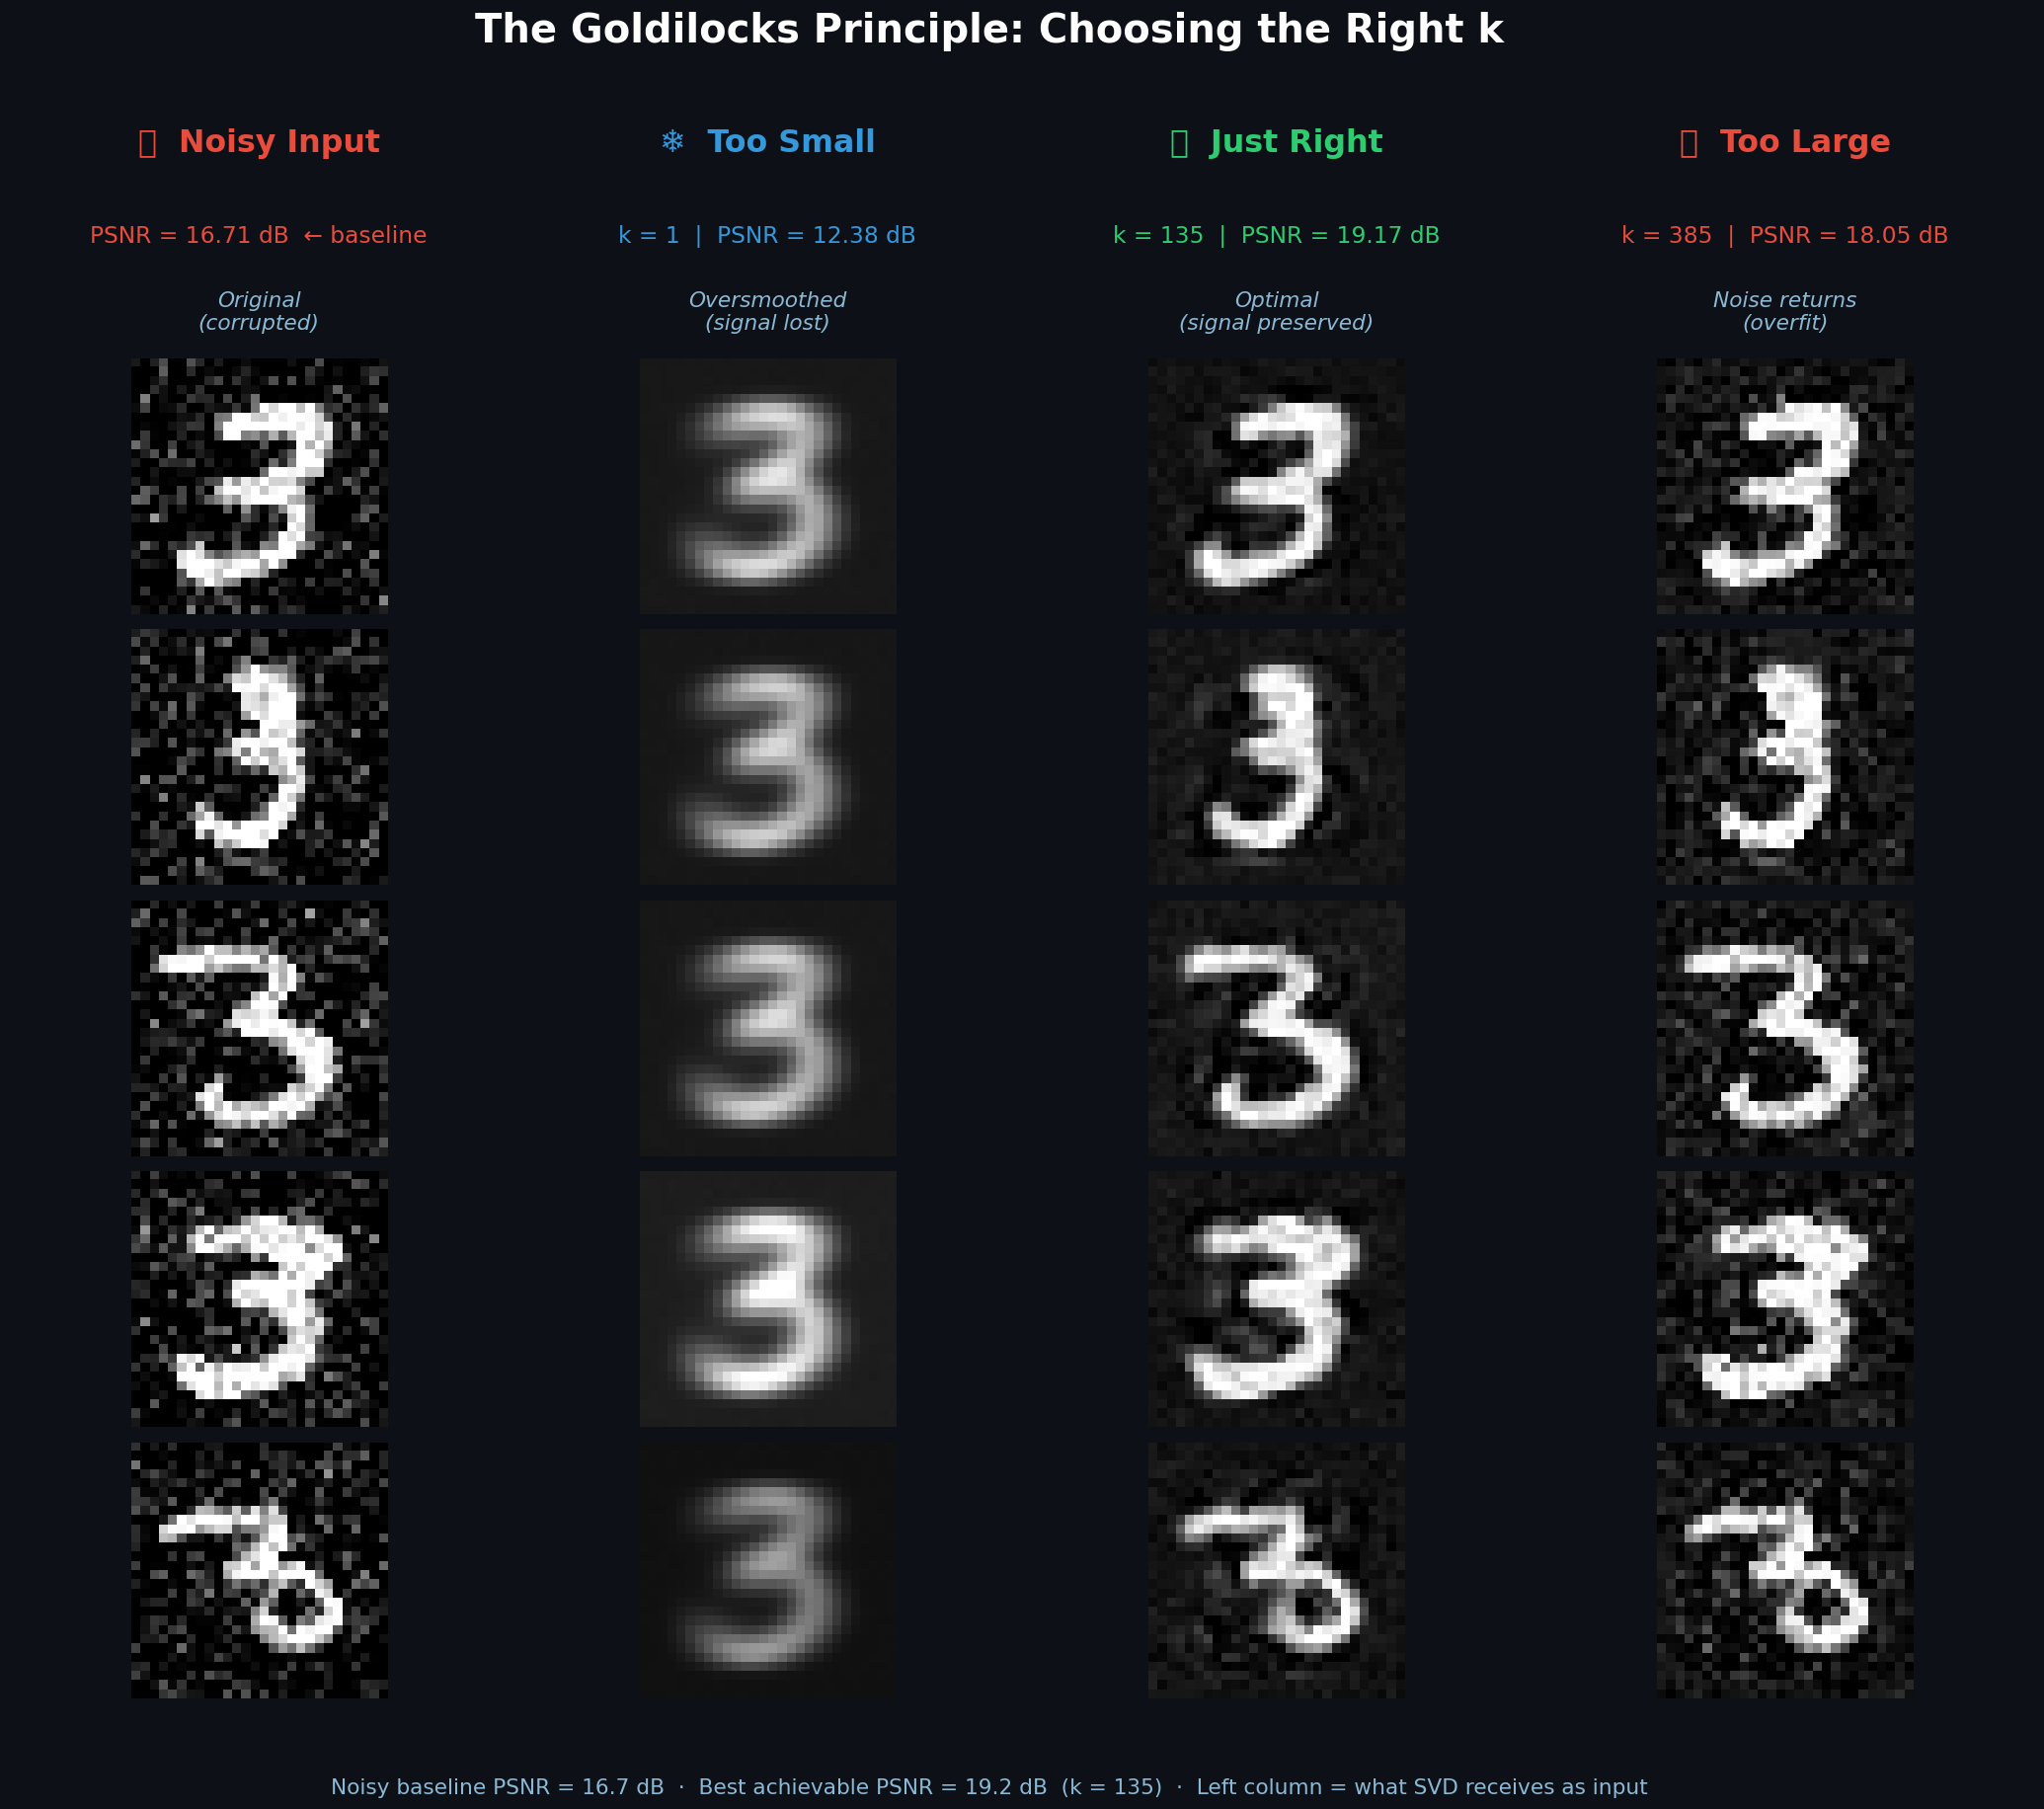

In [50]:
# ============================================================
# CELL 13: The Goldilocks Principle — 4-Column Dramatic Demo
# ============================================================
k_too_small = 1
k_optimal   = OPTIMAL_K
k_too_large = min(OPTIMAL_K+250, k_max)

configs = [
    (None,        '🔴  Noisy Input',  '#e74c3c', 'Original\n(corrupted)'),
    (k_too_small, '❄️  Too Small',    '#3498db', 'Oversmoothed\n(signal lost)'),
    (k_optimal,   '🎯  Just Right',   '#2ecc71', 'Optimal\n(signal preserved)'),
    (k_too_large, '🔥  Too Large',    '#e74c3c', 'Noise returns\n(overfit)'),
]

N_SAMPLE = 5

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('#0d1117')

fig.text(0.5, 0.97,
         'The Goldilocks Principle: Choosing the Right k',
         ha='center', va='top', fontsize=24,
         color='white', fontweight='bold')

gs = gridspec.GridSpec(N_SAMPLE + 1, 4, figure=fig,
                       hspace=0.06, wspace=0.03,   # ← wspace reduced from 0.10 to 0.03
                       top=0.93, bottom=0.08)

for col, (k_val, label, color, note) in enumerate(configs):

    # ── Get images for this column ────────────────────────────
    if k_val is None:
        images   = X_3_noisy
        p_val    = psnr(X_3, X_3_noisy)
        psnr_str = f'PSNR = {p_val:.2f} dB  ← baseline'
    else:
        images   = reconstruct(k_val)
        p_val    = psnr(X_3, images)
        psnr_str = f'k = {k_val}  |  PSNR = {p_val:.2f} dB'

    # ── Column header ─────────────────────────────────────────
    ax_title = fig.add_subplot(gs[0, col])
    ax_title.set_facecolor('#0d1117')
    ax_title.axis('off')

    # Column label — bigger
    ax_title.text(0.5, 0.78, label,
                  ha='center', va='center',
                  fontsize=19, color=color, fontweight='bold')  # ← 15 → 19

    # PSNR info — bigger
    ax_title.text(0.5, 0.42, psnr_str,
                  ha='center', va='center',
                  fontsize=14, color=color)                     # ← 11 → 14

    # Note — bigger
    ax_title.text(0.5, 0.12, note,
                  ha='center', va='center',
                  fontsize=13, color='#8bb8d4', style='italic') # ← 10 → 13

    # ── Sample images ─────────────────────────────────────────
    for row in range(N_SAMPLE):
        ax = fig.add_subplot(gs[row + 1, col])
        ax.imshow(images[row].reshape(28, 28),
                   cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        # Sample number on first column only
        if col == 0:
            ax.set_ylabel(f'#{row+1}', color='#566070',
                           fontsize=11, rotation=0,
                           labelpad=20, va='center')

# ── Bottom note ───────────────────────────────────────────────
fig.text(0.5, 0.03,
         f'Noisy baseline PSNR = {psnr(X_3, X_3_noisy):.1f} dB  '
         f'·  Best achievable PSNR = {best_psnr:.1f} dB  (k = {best_k})  '
         f'·  Left column = what SVD receives as input',
         ha='center', fontsize=13, color='#8bb8d4')

plt.show()

---
## Cell 14 — 📊 Quantitative Summary

In [32]:
# ============================================================
# CELL 14: Full Quantitative Summary Table
# ============================================================

p_noisy = psnr(X_3, X_3_noisy)

summary = [
    ('Noisy digit 3s',                  None,          X_3_noisy),
    (f'Denoised  k={k_too_small} (too small)', k_too_small, reconstruct(k_too_small)),
    (f'Denoised  k={OPTIMAL_K} (optimal)',     OPTIMAL_K,   reconstruct(OPTIMAL_K)),
    (f'Denoised  k={k_too_large} (too large)', k_too_large, reconstruct(k_too_large)),
    ('Clean digit 3s (ground truth)',    k_max,         X_3),
]

print("┌─────────────────────────────────────────┬───────┬──────────┬───────────────────┐")
print("│ Configuration                           │   k   │ PSNR(dB) │ Energy Captured   │")
print("├─────────────────────────────────────────┼───────┼──────────┼───────────────────┤")

for name, k_val, imgs in summary:
    p     = psnr(X_3, imgs)
    k_str = str(k_val) if k_val is not None else '—'
    if k_val is None or k_val == k_max:
        e_str = '—'
    else:
        e_str = f"{cum_energy[k_val-1]*100:.1f}%"
    print(f"│ {name:<39} │ {k_str:>5} │ {p:>8.2f} │ {e_str:>17} │")

print("└─────────────────────────────────────────┴───────┴──────────┴───────────────────┘")
print()
print(f"★  Best denoising at k = {OPTIMAL_K}")
print(f"   PSNR gain over noisy: +{best_psnr - p_noisy:.2f} dB")
print(f"   Using {OPTIMAL_K}/{k_max} = {100*OPTIMAL_K/k_max:.1f}% of all singular components")
print(f"   Storage savings: {k_max}×{P} → {OPTIMAL_K}×({N}+{P}) = "
      f"{k_max*P:,} → {OPTIMAL_K*(N+P):,} numbers")


┌─────────────────────────────────────────┬───────┬──────────┬───────────────────┐
│ Configuration                           │   k   │ PSNR(dB) │ Energy Captured   │
├─────────────────────────────────────────┼───────┼──────────┼───────────────────┤
│ Noisy digit 3s                          │     — │    16.71 │                 — │
│ Denoised  k=1 (too small)               │     1 │    12.38 │             57.2% │
│ Denoised  k=135 (optimal)               │   135 │    19.17 │             88.7% │
│ Denoised  k=285 (too large)             │   285 │    18.57 │             93.2% │
│ Clean digit 3s (ground truth)           │   784 │      inf │                 — │
└─────────────────────────────────────────┴───────┴──────────┴───────────────────┘

★  Best denoising at k = 135
   PSNR gain over noisy: +2.46 dB
   Using 135/784 = 17.2% of all singular components
   Storage savings: 784×784 → 135×(6131+784) = 614,656 → 933,525 numbers


## 🎯 Closing Reflection

<div style="background:linear-gradient(135deg, #0d1117 0%, #0d2137 100%);
     padding:36px 40px; border-radius:12px;
     border:1px solid #30a3dc; margin:16px 0;">

<h3 style="color:#30a3dc; margin-top:0;">What We Just Did</h3>

<table style="width:100%; border-collapse:collapse; margin-bottom:16px;">
<tr style="background:#0d2137;">
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc; text-align:left;">Step</th>
  <th style="color:#30a3dc; padding:8px; border:1px solid #30a3dc; text-align:left;">What happened</th>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;">Loaded ~6,131 images of digit 3</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Built a matrix: each row = one flattened 28×28 image</td>
</tr>
<tr style="background:#0d2137;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;">Added heavy Gaussian noise</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Every pixel corrupted — digits barely readable</td>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;">Computed SVD on the noisy matrix</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Found the shared structure across all 6,131 noisy images</td>
</tr>
<tr style="background:#0d2137;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;">Truncated to rank k</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Kept signal-dominant components, discarded noise-dominated ones</td>
</tr>
<tr style="background:#0f1923;">
  <td style="color:#2ecc71; padding:8px; border:1px solid #1e3a52;">Reconstructed</td>
  <td style="color:#ffffff; padding:8px; border:1px solid #1e3a52;">Clean, readable digit 3s — from noise</td>
</tr>
</table>

<h3 style="color:#2ecc71; margin-top:24px;">The Deep Insight</h3>

<div style="background:#0d2137; border-left:4px solid #2ecc71; padding:14px 18px; border-radius:6px; margin-bottom:16px;">
<p style="color:#ffffff; margin:0;">
SVD works here because <b style="color:#2ecc71;">all handwritten 3s share common structure</b> —
the loop at the top, the curve at the bottom, the general orientation.<br><br>
That shared structure is <b style="color:#2ecc71;">low-rank</b>. 
The noise is different in every image — <b style="color:#e74c3c;">high-rank</b>.<br><br>
SVD separates them automatically.
</p>
</div>

<h3 style="color:#f39c12; margin-top:24px;">This Scales to Any Domain</h3>

<p style="color:#ffffff;">The exact same pipeline works for:</p>

<p style="color:#ffffff;">
🎬 <b style="color:#f39c12;">Movie recommendations</b> 
<span style="color:#ffffff;">— users share taste patterns (low-rank)</span>
</p>

<p style="color:#ffffff;">
🧬 <b style="color:#f39c12;">Genomics</b> 
<span style="color:#ffffff;">— patients share disease subtypes (low-rank)</span>
</p>

<p style="color:#ffffff;">
📡 <b style="color:#f39c12;">Radar</b> 
<span style="color:#ffffff;">— targets share reflection signatures (low-rank)</span>
</p>

<div style="text-align:center; margin-top:20px; padding:14px; background:#0d2137; border-radius:8px; border:1px solid #30a3dc;">
<p style="color:#30a3dc; font-size:1.2em; margin:0;">
<b>One mathematical idea. Infinite applications.</b>
</p>
</div>

</div>

---
<p style="color:#566070; font-style:italic; font-size:0.9em;">
Notebook: SVD Denoising — MNIST Digit 3 | Advanced Predictive Models for Complex Data
</p>
